# **Guia de Trabajos Prácticos 2: Paradigma Orientado a Objetos**

Última modificación: 11/04/2024 23:00:00


# Problema 9: Egresados
Dado el siguiente diagrama de UML, se implementó el comportamiento que cuenta la cantidad de egresados y muestra el promedio de cada uno de ellos. Teniendo en cuenta las reglas del buen diseño, evalúe el siguiente código y modifíquelo si fuera necesario. Justifique cada una de las modificaciones

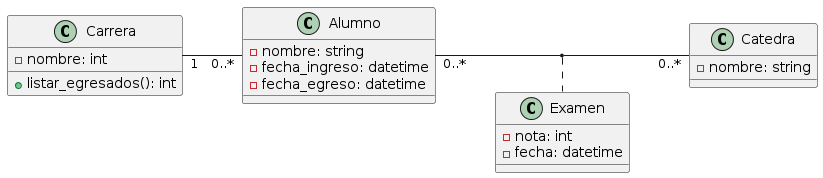

Código del diagrama para [planttext.com](https://www.planttext.com/)

```
@startuml
left to right direction

class Carrera {
    - nombre: int
    + listar_egresados(): int
}

class Alumno {
    - nombre: string
    - fecha_ingreso: datetime
    - fecha_egreso: datetime
}

class Catedra {
    - nombre: string
}

class Examen {
    - nota: int
    - fecha: datetime
}

Carrera "1" -- "0..*" Alumno
Alumno "0..*" -- "0..*" Catedra
(Alumno, Catedra) .. Examen

@enduml

```


Ayuda: consultar el funcionamiento de la funciones `iter()` y `next()`: https://www.programiz.com/python-programming/methods/built-in/next

In [ ]:
from typing import List
from datetime import datetime

class Carrera:
    def __init__(self):
        self.c_alumnos: List[Alumno] = []

    # Este método cuenta la cantidad de egresados de la carrera
    # y muestra el promedio de cada uno de ellos (Sin desaprobados)
    def listar_egresados(self) -> int:
        cant_egresados = 0
        # Recorro todos los alumnos de la CARRERA
        iter_alumnos = iter(self.c_alumnos)
        alumno = next(iter_alumnos, None)
        while alumno is not None:
            f_egreso = alumno.fecha_egreso
            if f_egreso is not None:
                cant_egresados += 1
                # Recorro todas las NOTAS de los ALUMNOS
                acumula_notas = 0
                cant_examenes_aprobados = 0
                for examen in alumno.examenes:
                    if examen.nota >= 6:
                        acumula_notas += examen.nota
                        cant_examenes_aprobados += 1
                promedio = acumula_notas / cant_examenes_aprobados
                print(f"Egresado {alumno.nombre} - Promedio: {promedio:.2f}")
            alumno = next(iter_alumnos, None)
        return cant_egresados

class Examen:
    def __init__(self, nota: float):
        self.nota = nota

class Alumno:
    def __init__(self, nombre: str, fecha_egreso: datetime, examenes: List['Examen']):
        self.nombre = nombre
        self.fecha_egreso = fecha_egreso
        self.examenes = examenes


# Ejemplo de uso
if __name__ == "__main__":
    alumno1 = Alumno("Juan", None, [Examen(7), Examen(8), Examen(5)])
    alumno2 = Alumno("María", None, [Examen(6), Examen(7), Examen(6)])
    carrera = Carrera()
    carrera.c_alumnos = [alumno1, alumno2]
    carrera.listar_egresados()


# Problema 10: Cátedras

Complete o modifique el diagrama UML del ejercicio anterior teniendo en cuenta el siguiente enunciado:

*En una universidad, hay alumnos y docentes. Los alumnos pertenecen a una Carrera y cursan Materias (Cátedras) en distintas Comisiones. Rinden exámenes parciales y finales, de los cuales obtienen una nota.*

*Cada Cátedra puede tener una o más Comisiones. Una Comisión está a cargo de un docente titular, tiene una fecha de inicio académico y se identifica con una letra, como "A", "B", etc.*

Consideraciones:

- Una misma persona puede ser alumno de más de una carrera.
- Codificar el siguiente comportamiento: Dada una Cátedra, listar los alumnos de todas las Comisiones que tenga en el año en curso:
`Universidad.listar_alumnos(catedra: Catedra)`


# Problema 11: Jerarquía

Si utilizó una jerarquía de herencias en el ejercicio anterior , reemplace las clases superiores (abstractas) por interfaces.

# Problema 12: Banco

CDRG es un banco multinacional que trabaja con un único tipo de cuenta. Cada cuenta conoce a su titular (apellido, nombre y CUIL) y la historia de transacciones, que pueden ser de **depósito**, **extracción** y **consulta de saldo**. Todas las transacciones poseen una fecha asociada. Además, las de depósito y extracción incluyen el monto de la operación. El banco opera con distintas monedas, por lo que el monto se indica como una cantidad de dinero y la moneda en que se realiza la operación. Las monedas pueden ser: **peso**, **dólar** y **real**.

a) Hacer el diagrama UML especificando la asociación entre clases, cardinalidad y navegabilidad para este dominio.

b) Implemente el siguiente comportamiento, respetando el diagrama del ejercicio anterior:

>El banco cobra una comisión de administración de la cuenta en función del total de transacciones de un período. Para determinar dicho costo, aplica la siguiente fórmula: (a) La cantidad de transacciones del período (b) Sumatoria de transacciones del período en pesos argentinos (moneda base) 30 – ( (b / a) x 0.5 % ) = comisión
>
>Por ejemplo: (20,000 / 20) = 1,000 => 1,000 * 0.005 = 5 => 30 – 5 = $ 25

Listar las comisiones de cada una de las cuentas del banco. Detallando el número de cuenta y el monto (siempre en pesos) de la comisión.

Ayuda: Monto >> convertir_a_peso(): Convierte el monto a Peso. Por ejemplo, para convertir 400 guaraníes a pesos (400 g / 200, la relación contra el peso) son 2 pesos. Piense dónde recae esta responsabilidad **teniendo en cuenta TDA y DEMETER**. Tenga en cuenta que las relaciones de conversión de monedas **son variables**.

# Problema 13: Principios SOLID

Modifica los siguientes fragmentos de código de manera de que cumplir con los principios SOLID. Explicitar qué principio se viola en cada caso (salvo en el de Correo Electrónico).

## Empleado


In [ ]:
class Empleado:
    def __init__(self, nombre, horas_trabajadas, tarifa_por_hora):
        self.nombre = nombre
        self.horas_trabajadas = horas_trabajadas
        self.tarifa_por_hora = tarifa_por_hora

    def calcular_salario(self):
        return self.horas_trabajadas * self.tarifa_por_hora

    def generar_reporte_desempenio(self):
        # Código para generar el reporte de desempeño
        pass


se viola el principio: ...



## Correo electrónico

Utilizando el Principio de Inversión de Dependencias (DIP), modificar el siguiente código de manera que se puedan incorporar otros mecanismos de comunicación además de Correo Electrónico para enviar notificaciones.

In [ ]:
class CorreoElectronico:
    def enviar_notificacion(self, destinatario: str, mensaje: str):
        # Lógica para enviar notificación por correo electrónico
        print(f"Correo electrónico enviado a {destinatario}: {mensaje}")

class Notificador:
    def __init__(self, correo_electronico: CorreoElectronico):
        self.correo_electronico = correo_electronico

    def enviar_notificacion(self, destinatario: str, mensaje: str):
        self.correo_electronico.enviar_notificacion(destinatario, mensaje)

# Uso del código actual
correo_electronico = CorreoElectronico()
notificador = Notificador(correo_electronico)
notificador.enviar_notificacion("usuario@example.com", "¡Tu tarea está lista!")


se viola el principio: ...



## Supermercado

In [1]:
class Producto:
    def __init__(self, nombre: str, categoria: str):
        self.nombre = nombre
        self.categoria = categoria

class Carrito:
    def __init__(self, productos: list):
        self.productos = productos

def calcular_descuento(productos: list):
    for producto in productos:
        if producto.categoria == 'alimentos':
            print(f"Descuento del 10% en {producto.nombre}")
        elif producto.categoria == 'limpieza':
            print(f"Descuento del 5% en {producto.nombre}")
        # Añadir más condiciones para nuevos tipos de productos y descuentos

productos = [
    Producto('manzanas', 'alimentos'),
    Producto('jabón', 'limpieza')
]

carrito = Carrito(productos)
calcular_descuento(carrito.productos)


Descuento del 10% en manzanas
Descuento del 5% en jabón


se viola el principio: ...

## Service de reparación de dispositivos móviles

In [ ]:
class Dispositivo:
    def __init__(self, marca: str, modelo: str):
        self.marca = marca
        self.modelo = modelo

class Celular(Dispositivo):
    def __init__(self, marca: str, modelo: str, pantalla: bool):
        super().__init__(marca, modelo)
        self.pantalla = pantalla

class Tablet(Dispositivo):
    def __init__(self, marca: str, modelo: str, pantalla: bool, lapiz: bool):
        super().__init__(marca, modelo)
        self.pantalla = pantalla
        self.lapiz = lapiz

class Smartwatch(Dispositivo):
    def __init__(self, marca: str, modelo: str, pantalla: bool, gps: bool):
        super().__init__(marca, modelo)
        self.pantalla = pantalla
        self.gps = gps

def contar_piezas_reparacion(dispositivos: list):
    for dispositivo in dispositivos:
        if isinstance(dispositivo, Celular):
            print(contar_piezas_celular(dispositivo))
        elif isinstance(dispositivo, Tablet):
            print(contar_piezas_tablet(dispositivo))
        elif isinstance(dispositivo, Smartwatch):
            print(contar_piezas_smartwatch(dispositivo))

# Funciones para contar piezas de repuesto específicas para cada tipo de dispositivo
def contar_piezas_celular(celular: Celular):
    return "Piezas requeridas para reparar el celular"

def contar_piezas_tablet(tablet: Tablet):
    return "Piezas requeridas para reparar la tablet"

def contar_piezas_smartwatch(smartwatch: Smartwatch):
    return "Piezas requeridas para reparar el smartwatch"

# Ejemplo de uso
dispositivos = [
    Celular("Samsung", "Galaxy S20", True),
    Tablet("Apple", "iPad Pro", True, True),
    Smartwatch("Apple", "Watch Series 6", True, True)
]

contar_piezas_reparacion(dispositivos)


se viola el principio: ...



## Sala de estudio

In [ ]:
from abc import ABC, abstractmethod

class IUsuario(ABC):
    @abstractmethod
    def solicitar_prestamo_libro(self):
        pass

    @abstractmethod
    def devolver_libro(self):
        pass

    @abstractmethod
    def buscar_libro(self):
        pass

    @abstractmethod
    def solicitar_reserva_sala_estudio(self):
        pass

class Estudiante(IUsuario):
    def solicitar_prestamo_libro(self):
        print("Estudiante solicitando préstamo de libro.")

    def devolver_libro(self):
        print("Estudiante devolviendo libro.")

    def buscar_libro(self):
        print("Estudiante buscando libro en el catálogo.")

    def solicitar_reserva_sala_estudio(self):
        raise NotImplementedError("Los estudiantes no pueden reservar salas de estudio.")

class Profesor(IUsuario):
    def solicitar_prestamo_libro(self):
        print("Profesor solicitando préstamo de libro.")

    def devolver_libro(self):
        print("Profesor devolviendo libro.")

    def buscar_libro(self):
        print("Profesor buscando libro en el catálogo.")

    def solicitar_reserva_sala_estudio(self):
        print("Profesor solicitando reserva de sala de estudio.")

# Ejemplo de uso
estudiante = Estudiante()
profesor = Profesor()

estudiante.solicitar_prestamo_libro()
estudiante.devolver_libro()
estudiante.buscar_libro()

profesor.solicitar_prestamo_libro()
profesor.devolver_libro()
profesor.buscar_libro()
profesor.solicitar_reserva_sala_estudio()


se viola el principio: ...



# Material de apoyo

## Métodos Privados en Python

Los métodos privados son aquellos que están destinados a ser utilizados internamente dentro de una clase y no deben ser accedidos desde fuera de la clase. Aunque Python no tiene verdaderos métodos privados como en otros lenguajes como C++, se sigue una convención de nomenclatura para identificarlos.

Los métodos privados en Python se nombran con uno o dos guiones bajos `_` como prefijo en el nombre del método. Esta convención indica que el método es privado y *no debe* ser accedido desde fuera de la clase.

A pesar de que *los métodos privados pueden ser accedidos desde fuera de la clase*, la convención de nomenclatura indica que no deberían ser accedidos directamente.

Si se quiere evitar su uso accidental, puede utilizarse el doble guión bajo ([name mangling](https://www.geeksforgeeks.org/name-mangling-in-python/)) para que el acceso se torne un poco más complejo por parte del usuario. Ejemplo:


In [ ]:
class MiClase:
    def __init__(self):
        self.__atributo_privado = 42  # Atributo privado con doble guion bajo

    def _metodo_privado_snm(self):  # un guion bajo al inicio
        return "Este es un método privado (sin name mangling)"

    def __metodo_privado_cnm(self):  # dos guiones bajos al inicio
        return "Este es un método privado (con name mangling)"

    def metodo_publico(self):
        print("Este es un método público")
        print("Accediendo al método privado con name mangling desde dentro de la clase:", self.__metodo_privado_cnm())
        print("Accediendo al método privado sin name mangling desde dentro de la clase:", self._metodo_privado_snm())

# Crear una instancia de la clase
objeto = MiClase()

# Acceder al método público
objeto.metodo_publico()

# Intentar acceder al método privado desde fuera de la clase (no es recomendado)
# Esto funcionará técnicamente, pero no es una práctica recomendada
print("Intentando acceder al método privado sin name mangling desde fuera de la clase:", objeto._metodo_privado_snm())  # Funciona

Este es un método público
Accediendo al método privado con name mangling desde dentro de la clase: Este es un método privado (con name mangling)
Accediendo al método privado sin name mangling desde dentro de la clase: Este es un método privado (sin name mangling)
Intentando acceder al método privado sin name mangling desde fuera de la clase: Este es un método privado (sin name mangling)


In [ ]:
print("Intentando acceder al método privado con name mangling desde fuera de la clase:", objeto.__metodo_privado_cnm())  # No funciona

AttributeError: 'MiClase' object has no attribute '__metodo_privado_cnm'

cuando se utiliza name mangling, se puede acceder de todas formas (aunque no es lo recomendable) haciendo:

In [ ]:
print("Intentando acceder al método privado con name mangling desde fuera de la clase:", objeto._MiClase__metodo_privado_cnm())

Intentando acceder al método privado con name mangling desde fuera de la clase: Este es un método privado (con name mangling)


## Uso de listas en Python

En Python, las listas son una estructura de datos flexible y poderosa que puede contener una colección ordenada de elementos. Se pueden crear listas utilizando corchetes `[]` y separando los elementos por comas. Aquí hay algunos ejemplos de cómo trabajar con listas en Python:

### Crear una lista



In [ ]:
# Crear una lista vacía
lista_vacia = []

# Crear una lista con elementos
numeros = [1, 2, 3, 4, 5]
nombres = ["Juan", "María", "Carlos"]

# Listas pueden contener diferentes tipos de datos
mixta = [1, "dos", 3.0, True]

In [ ]:
# Acceder a elementos por su índice (comenzando desde 0)
print(numeros[0])  # Salida: 1
print(nombres[1])  # Salida: María

# Acceder a elementos desde el final con índices negativos
print(numeros[-1])  # Salida: 5

1
María
5


In [ ]:
numeros[0] = 10
print(numeros)  # Salida: [10, 2, 3, 4, 5]

# Agregar elementos al final de la lista
numeros.append(6)
print(numeros)  # Salida: [10, 2, 3, 4, 5, 6]

[10, 2, 3, 4, 5]
[10, 2, 3, 4, 5, 6]


In [ ]:
# Obtener la longitud de la lista
print(len(nombres))  # Salida: 3

# Iterar sobre los elementos de la lista
for nombre in nombres:
    print(nombre)

3
Juan
María
Carlos


Las listas en Python son dinámicas y pueden contener cualquier tipo de datos, lo que las hace muy versátiles.

## ¿Por qué definir el main?

En este video (pensado para Python 2 pero el concepto sigue vigente), se muestra la importancia de definir el main en un script de Python, ya que, como habrán visto, en algunos casos da igual definirlo o no.

La cosa cambia cuando queremos importar código definido en otros scripts, y ahí el main sí cobra importancia, ya que no siempre pensamos ejecutar el script, sino importarlo para utilizar definiciones del mismo.

El enlace del video es: https://youtu.be/sugvnHA7ElY. Está en inglés pero tiene subtítulos.

## Convenciones de nombres

Como habrás notado, en los diagramas UML se suele utilizar *lower camel case* (por ejemplo 'nombreDeVariable') para los nombres de las variables, funciones, atributos y métododos, pero en algunos ejemplos de código aparece otra convención ('nombre_de_variable'). Esto se debe a que en el caso de los diagramas UML, se siguen ciertas convenciones (leer la sección 7.5 "UML Class Notation" del [libro de Arlow](http://e-fich.unl.edu.ar/moodle/mod/page/view.php?id=106271)).

Sin embargo, en cada lenguaje se puede establecer otra convención. En el caso de Python, en el [PEP 8](https://peps.python.org/pep-0008/), se definen convenciones de estilo de código. Recomendamos leer un resumen del mismo en esta página: https://ellibrodepython.com/python-pep8.




## Tipado en Python

A pesar de que no sea necesario definir el tipo de cada variable en Python, desde Python 3.5 se agregó soporte a las *anotaciones de tipado* para algunos casos en donde es conveniente explicitar a qué clase pertenece, por ejemplo, un argumento de una función, como en el ejercicio 8:

```
def listar_empleados_por_jefe(o_jefe: Jefe):
    ...
```

En este caso se espera que o_jefe sea una instancia de la clase `Jefe`.

Leer la documentación ([Inglés](https://docs.python.org/3/library/typing.html)/[español](https://docs.python.org/es/3.8/library/typing.html)) para más información.

## Funciones útiles

Aquí una breve descripción de funciones que pueden ser de utilidad para esta unidad:

### `isinstance`

La función `isinstance` se utiliza para determinar si un objeto es una instancia de una clase o de una clase que hereda de otra clase. Esto es útil cuando necesitas realizar operaciones específicas según el tipo de objeto con el que estás tratando.

```python
class Animal:
    pass

class Perro(Animal):
    pass

d = Perro()
print(isinstance(d, Perro))   # Salida: True
print(isinstance(d, Animal))  # Salida: True
```

Documentación: [Función `isinstance`](https://docs.python.org/3/library/functions.html#isinstance)

---

### `issubclass`

La función `issubclass` se utiliza para determinar si una clase es una subclase de otra clase. Es útil cuando necesitas verificar las relaciones de herencia entre clases.

```python
class Animal:
    pass

class Perro(Animal):
    pass

print(issubclass(Perro, Animal))  # Salida: True
```

Documentación: [Función `issubclass`](https://docs.python.org/3/library/functions.html#issubclass)

---


### `super`

La función `super` se utiliza para acceder a métodos y atributos de la clase base desde una subclase que lo ha sobrescrito. Esto es útil cuando necesitas llamar al constructor de la clase base u otros métodos de la clase base.

```python
class Animal:
    def hacer_sonido(self):
        return "Grrr"

class Perro(Animal):
    def hacer_sonido(self):
        return super().hacer_sonido() + " Woof!"

d = Perro()
print(d.hacer_sonido())  # Salida: Grrr Woof!
```

Documentación: [Función `super`](https://docs.python.org/3/library/functions.html#super)

---


#### `__str__` y `__repr__`

En Python, `__str__` y `__repr__` son métodos especiales utilizados para definir cómo se debe representar una instancia de una clase en forma de cadena. Aunque pueden parecer similares, tienen propósitos ligeramente diferentes:

- `__str__`: Este método devuelve una representación legible para humanos de un objeto. Es utilizado por la función `str()` y por la función `print()` cuando se quiere obtener una versión "amigable" del objeto.

- `__repr__`: Este método devuelve una representación sin ambigüedades del objeto, preferiblemente algo que permita crear una instancia igual al objeto original. Es utilizado por la función `repr()` y por el intérprete cuando se muestra un objeto como el resultado de una expresión.

La principal diferencia radica en la intención de uso: `__str__` se utiliza para mostrar información legible para humanos, mientras que `__repr__` se utiliza para representar la forma precisa del objeto, útil para propósitos de depuración y reproducción del objeto.

**Ejemplo de diferencia:**

```python
class Punto:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        return f'({self.x}, {self.y})'

    def __repr__(self):
        return f'Punto({self.x}, {self.y})'

p = Punto(3, 4)
print(str(p))   # Salida: (3, 4)
print(repr(p))  # Salida: Punto(3, 4)
```

En este ejemplo, `__str__` devuelve una representación legible para humanos `(3, 4)`, mientras que `__repr__` devuelve una representación más precisa y útil para recrear el objeto `Punto(3, 4)`.

## Interfaces en Python

A diferencia de otros lenguajes como Java que poseen una sintaxis especial para este tipo de abstracciones, en Python podemos definir interfaces de la siguiente manera:

```python
# Importar ABC (Abstract Base Classes) del módulo abc
from abc import ABC, abstractmethod

# Definición de la interfaz en Python
class Animal(ABC):
    @abstractmethod
    def hacer_sonido(self):
        pass

# Clase que implementa la interfaz en Python
class Perro(Animal):
    def hacer_sonido(self):
        print("Guau!")

# Clase que utiliza la interfaz en Python
if __name__ == "__main__":
    animal = Perro()
    animal.hacer_sonido()  # Salida: Guau!
```

en este caso, `Animal` cumple el rol de una interfaz, que contiene un método `hacer_sonido` que debe ser deifnido por las clases que implementen la misma.

Notar que una interfaz define un conjunto de métodos que una clase debe implementar. Si bien Python permite que en una interfaz definamos atributos, esto no sería correcto teóricamente, por lo que hay que tener en cuenta que los mismos deben estar declarados en las clases que implementen dicha interfaz.

Además, se pueden implementar varias interfaces dentro de una misma clase a través de la herencia múltiple. Consultar en la documentación oficial de Python (https://docs.python.org/3/tutorial/classes.html#multiple-inheritance), y el siguiente artículo: [https://medium.com/@shashikantrbl123/interfaces-and-abstract-classes-in-python-understanding-the-differences-3e5889a0746a](http://archive.today/M2XTh)